# Random Forest — Fake News Classifier

Binary classification of political statements as true (0) or false (1).

**NOTE**: The training scripts I used for every training session are in `src\training\`. This is the code of the "latest" version of `randomForestClassifier.py`. All Markdown cells are from my notes, and generated using copilot. 



Random Forest is the first tree-based ensemble in the project. After Logistic Regression plateaued (~0.60 macro F1), RFC offered two key advantages:
- **Non-linear boundaries**: can learn complex interactions between speaker, topic, and text features without explicit feature crosses.
- **Built-in feature selection**: random feature subsampling per split (`max_features`) provides implicit regularisation and makes the model robust to correlated features (like the 384 embedding dimensions).

**Architecture:**
- Sentence embeddings (`all-MiniLM-L6-v2`, 384-dim) for the statement text
- Rich metadata: subject, speaker, party, speaker job, state (with frequency encoding, grouping, interaction keys)
- True-rate features computed fold-safe inside the CV loop (all four: speaker, subject, party, job)
- Nested CV: 5-fold outer, 3-fold inner `RandomizedSearchCV` (20 trials per fold)
- Threshold tuning on OOF probabilities, optimising macro F1
- **OrdinalEncoder** for grouped categorical strings and interaction keys (OneHotEncoder rejected due to high cardinality)

**Metric:** Macro F1

## Imports and Project Setup

The `find_project_root` helper walks up the directory tree until it finds the `data/train.csv` file, so this notebook runs correctly from any subdirectory.

In [1]:
from collections import Counter
from datetime import datetime
from pathlib import Path
import sys
from time import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'train.csv').exists() and (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError('Could not locate the project root.')

project_root = find_project_root(Path.cwd())
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from preprocessing.one_step import OneStepOptions, preprocess_one_step

print(f'Project root: {project_root}')

_script_start = time()
def _now() -> str:
    return datetime.now().strftime('%H:%M:%S')

c:\Users\CmdrC\anaconda3\envs\sitc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp


## Data Loading

8,950 labeled training samples. Columns: `id`, `label`, `statement`, `subject`, `speaker`, `speaker_job`, `state_info`, `party_affiliation`.

Class distribution: ~35% true (0), ~65% false (1). The imbalance is handled via `class_weight={0: 1.42, 1: 0.77}` — computed as `n_samples / (2 * n_class_i)`. This scales the impurity criterion during tree growth, so the forest gives equal weight to both classes regardless of how many samples each has.

In [2]:
df = pd.read_csv(project_root / 'data' / 'train.csv')
print(f'Shape: {df.shape}')
print(f"\nLabel distribution:\n{df['label'].value_counts(normalize=True).round(4)}")
df.head()

Shape: (8950, 8)

Label distribution:
label
1    0.6475
0    0.3525
Name: proportion, dtype: float64


,id,label,statement,subject,speaker,speaker_job,state_info,party_affiliation
0,81f884c64a7,1,China is in the South China Sea and (building)...,"china,foreign-policy,military",donald-trump,President-Elect,New York,republican
1,30c2723a188,0,With the resources it takes to execute just ov...,health-care,chris-dodd,U.S. senator,Connecticut,democrat
2,6936b216e5d,0,The (Wisconsin) governor has proposed tax give...,"corporations,pundits,taxes,abc-news-week",donna-brazile,Political commentator,"Washington, D.C.",democrat
3,b5cd9195738,1,Says her representation of an ex-boyfriend who...,"candidates-biography,children,ethics,families,...",rebecca-bradley,NaN,NaN,none
4,84f8dac7737,0,At protests in Wisconsin against proposed coll...,"health-care,labor,state-budget",republican-party-wisconsin,NaN,Wisconsin,republican


## Preprocessing Configuration

All preprocessing is controlled through `OneStepOptions`. Each module is configured independently below.

Key decisions for Random Forest (vs Logistic Regression):

| Setting | LR | RFC | Reason |
|---|---|---|---|
| Scaling | `standardize` | `none` | Trees split on thresholds — invariant to monotone transforms |
| Stemmer | Porter | `none` | Trees may use token distinctions that stemming erases |
| Stopword removal | OFF | OFF | Embeddings need natural language in both cases |
| NER features | OFF | ON | Tree can split on entity counts; LR had too many features already |
| Interaction keys | OFF | ON | Trees split directly on joint categorical keys — no manual feature cross needed for LR |
| Embeddings | `all-MiniLM-L6-v2` | `all-MiniLM-L6-v2` | Same 384-dim vectors |

All `*_scale = 'none'` settings skip the StandardScaler for that module — trees gain nothing from scaled inputs.

In [3]:
# --- Label & ID ---
label_option      = 'skip'   # keep label column for training
label_source_col  = 'label'
id_option         = 'drop'

# --- Subject ---
subject_source_col             = 'subject'
subject_keep_original          = False
subject_clean_text             = True
subject_normalize_separators   = True
subject_split_topics           = True
subject_primary_strategy       = 'most_frequent'  # most stable across CV splits
subject_rare_threshold         = 10
subject_rare_label             = 'other'
subject_max_topics_for_primary = None
subject_multi_topic_label      = 'multi-topic'
subject_add_primary            = True
subject_add_topic_count        = True
subject_add_multiple_topics_flag = True
subject_add_topic_list         = False
subject_add_length_features    = True
subject_add_grouped_primary    = True
subject_group_rare             = True
subject_add_subject_frequency  = True
subject_add_subject_is_rare    = True
subject_add_subject_primary_true_rate = False  # computed fold-safe in CV loop
subject_label_col              = None
subject_scale                  = 'none'
subject_verbose                = False

In [4]:
# --- Statement ---
statement_source_col             = 'statement'
statement_original_output_col    = 'statement_original'
statement_output_col             = 'statement_clean'
statement_keep_original          = False
statement_lower                  = True
statement_remove_html            = True
statement_remove_urls            = True
statement_replace_numbers        = False
statement_number_token           = '<NUM>'
statement_stopword_removal       = False   # OFF: embeddings need natural language
statement_keep_negations         = True
statement_remove_punctuation     = False
statement_stemmer                = 'none'  # OFF: trees gain nothing from stemming
statement_lemmatizer             = 'none'
statement_repair_polluted_statements = True
statement_add_rare_token_features   = True
statement_rare_token_threshold      = 1
statement_token_freqs               = None
statement_add_spelling_errors       = True
statement_add_lexical_features      = True
statement_add_pollution_features    = True
statement_add_ner_features          = True   # PERSON, ORG, GPE, DATE entity counts
statement_ner_model                 = 'en_core_web_sm'
statement_vectorizer_type           = 'embeddings'
statement_vectorizer_max_features   = 500
statement_vectorizer_min_df         = 2
statement_vectorizer_max_df         = 0.7
statement_embedding_model           = 'all-MiniLM-L6-v2'  # 384-dim
statement_fitted_vectorizer         = None
statement_scale                     = 'none'
statement_verbose                   = False

In [5]:
# --- Speaker ---
speaker_source_col            = 'speaker'
speaker_keep_original         = False
speaker_clean_text            = True
speaker_normalize_separators  = True
speaker_group_rare            = True
speaker_rare_threshold        = 5
speaker_rare_label            = 'other'
speaker_add_frequency         = True
speaker_add_is_rare           = True
speaker_add_grouped_speaker   = True
speaker_add_length_features   = True
speaker_add_title_flag        = True
speaker_add_comma_flag        = True
speaker_add_period_flag       = True
speaker_add_token_count       = False
speaker_add_speaker_primary_true_rate = False
speaker_label_col             = None
speaker_scale                 = 'none'
speaker_verbose               = False

# --- Speaker job ---
speaker_job_source_col           = 'speaker_job'
speaker_job_keep_original        = False
speaker_job_clean_text           = True
speaker_job_normalize_separators = True
speaker_job_group_rare           = True
speaker_job_rare_threshold       = 5
speaker_job_rare_label           = 'other'
speaker_job_add_frequency        = True
speaker_job_add_is_rare          = True
speaker_job_add_grouped_job      = True
speaker_job_add_length_features  = True
speaker_job_add_title_flag       = True
speaker_job_add_comma_flag       = True
speaker_job_add_slash_flag       = True
speaker_job_add_ampersand_flag   = True
speaker_job_add_token_count      = False
speaker_job_add_job_primary_true_rate = False
speaker_job_job_label_col        = None
speaker_job_scale                = 'none'
speaker_job_verbose              = False

# --- Party affiliation ---
party_affiliation_source_col         = 'party_affiliation'
party_affiliation_keep_original      = False
party_affiliation_clean_text         = True
party_affiliation_group_rare         = True
party_affiliation_rare_threshold     = 5
party_affiliation_rare_label         = 'other'
party_affiliation_add_frequency      = True
party_affiliation_add_is_rare        = True
party_affiliation_add_grouped_party  = True
party_affiliation_add_length_features = True
party_affiliation_add_token_count    = True
party_affiliation_add_is_major_party = True
party_affiliation_add_is_institutional = True
party_affiliation_add_slash_flag     = True
party_affiliation_add_ampersand_flag = True
party_affiliation_add_comma_flag     = False
party_affiliation_add_parentheses_flag = True
party_affiliation_add_party_primary_true_rate = False
party_affiliation_party_label_col    = None
party_affiliation_scale              = 'none'
party_affiliation_verbose            = False

# --- State info ---
state_source_col        = 'state_info'
state_drop              = False
state_keep_original     = False
state_clean_text        = True
state_normalize_state   = True
state_group_rare        = True
state_rare_threshold    = 5
state_rare_label        = 'other'
state_add_is_us_state   = True
state_add_frequency     = True
state_add_is_rare       = True
state_add_grouped_state = True
state_add_has_us_words  = True
state_add_us_region     = True
state_add_length_features = False
state_add_token_count   = True
state_scale             = 'none'
state_verbose           = False

In [6]:
# --- Feature Engineering ---
# Three families:
#   1. Interaction keys — joint categorical strings for direct tree splitting
#      e.g. speaker_subject: "does speaker X lie on topic Y?"
#   2. True-rate aggregates — computed fold-safe inside CV loop (no leakage)
#   3. Text-style — linguistic deception signals from the statement

fe_statement_col          = 'statement_clean'
fe_statement_original_col = 'statement_original'
fe_speaker_col            = 'speaker_clean'
fe_subject_col            = 'subject_clean'
fe_party_col              = 'party_affiliation_clean'
fe_speaker_job_col        = 'speaker_job_clean'
fe_state_col              = 'state_info_clean'
fe_label_col              = None  # true-rates computed in CV loop, not here

# 1. Interaction features (joint string keys → OrdinalEncoded)
fe_add_speaker_subject              = True
fe_add_speaker_party                = True
fe_add_subject_party                = True
fe_add_speaker_job_subject          = True
fe_add_state_party                  = True
fe_add_speaker_statement_len_bucket = True
fe_statement_len_bins               = (50, 150)

# 2. True-rate aggregates — False here, recomputed fold-safe inside CV loop
fe_add_speaker_true_rate  = False
fe_add_subject_true_rate  = False
fe_add_party_true_rate    = False

# 2b. Non-leaking aggregates (computed on full dataset — no label info)
fe_add_speaker_avg_statement_len = True
fe_add_subject_avg_statement_len = True
fe_add_speaker_avg_punctuation   = True
fe_add_speaker_avg_number_ratio  = True

# 3. Text-style features
fe_add_negation_count    = True   # fake claims use more negations
fe_add_hedge_count       = True   # hedging = vague/unverifiable claims
fe_add_absolutist_count  = True   # absolutist language correlates with exaggeration
fe_add_numeral_count     = True   # specific numbers are a strong PolitiFact signal
fe_add_proper_noun_count = True
fe_add_readability       = True
fe_add_sentiment         = True

fe_scale    = 'none'
fe_verbose  = False

## Build OneStepOptions

`OneStepOptions` is a dataclass that bundles all preprocessing parameters into a single object passed to `preprocess_one_step`. Defined once here to guarantee consistency between the CV loop and the final fit.

In [7]:
options = OneStepOptions(
    label_option=label_option, label_source_col=label_source_col, id_option=id_option,
    subject_source_col=subject_source_col, subject_keep_original=subject_keep_original,
    subject_clean_text=subject_clean_text, subject_normalize_separators=subject_normalize_separators,
    subject_split_topics=subject_split_topics, subject_primary_strategy=subject_primary_strategy,
    subject_max_topics_for_primary=subject_max_topics_for_primary,
    subject_multi_topic_label=subject_multi_topic_label,
    subject_add_primary=subject_add_primary, subject_add_topic_count=subject_add_topic_count,
    subject_add_multiple_topics_flag=subject_add_multiple_topics_flag,
    subject_add_topic_list=subject_add_topic_list, subject_add_length_features=subject_add_length_features,
    subject_add_grouped_primary=subject_add_grouped_primary, subject_group_rare=subject_group_rare,
    subject_rare_threshold=subject_rare_threshold, subject_rare_label=subject_rare_label,
    subject_add_subject_frequency=subject_add_subject_frequency,
    subject_add_subject_is_rare=subject_add_subject_is_rare,
    subject_add_subject_primary_true_rate=subject_add_subject_primary_true_rate,
    subject_label_col=subject_label_col, subject_scale=subject_scale, subject_verbose=subject_verbose,
    statement_source_col=statement_source_col, statement_original_output_col=statement_original_output_col,
    statement_output_col=statement_output_col, statement_keep_original=statement_keep_original,
    statement_lower=statement_lower, statement_remove_html=statement_remove_html,
    statement_remove_urls=statement_remove_urls, statement_replace_numbers=statement_replace_numbers,
    statement_number_token=statement_number_token, statement_stopword_removal=statement_stopword_removal,
    statement_keep_negations=statement_keep_negations, statement_stemmer=statement_stemmer,
    statement_lemmatizer=statement_lemmatizer, statement_remove_punctuation=statement_remove_punctuation,
    statement_repair_polluted_statements=statement_repair_polluted_statements,
    statement_add_rare_token_features=statement_add_rare_token_features,
    statement_rare_token_threshold=statement_rare_token_threshold,
    statement_token_freqs=statement_token_freqs, statement_add_spelling_errors=statement_add_spelling_errors,
    statement_add_lexical_features=statement_add_lexical_features,
    statement_add_pollution_features=statement_add_pollution_features,
    statement_add_ner_features=statement_add_ner_features, statement_ner_model=statement_ner_model,
    statement_vectorizer_type=statement_vectorizer_type,
    statement_vectorizer_max_features=statement_vectorizer_max_features,
    statement_vectorizer_min_df=statement_vectorizer_min_df,
    statement_vectorizer_max_df=statement_vectorizer_max_df,
    statement_embedding_model=statement_embedding_model,
    statement_fitted_vectorizer=statement_fitted_vectorizer,
    statement_scale=statement_scale, statement_verbose=statement_verbose,
    speaker_source_col=speaker_source_col, speaker_keep_original=speaker_keep_original,
    speaker_clean_text=speaker_clean_text, speaker_normalize_separators=speaker_normalize_separators,
    speaker_group_rare=speaker_group_rare, speaker_rare_threshold=speaker_rare_threshold,
    speaker_rare_label=speaker_rare_label, speaker_add_frequency=speaker_add_frequency,
    speaker_add_is_rare=speaker_add_is_rare, speaker_add_grouped_speaker=speaker_add_grouped_speaker,
    speaker_add_length_features=speaker_add_length_features, speaker_add_title_flag=speaker_add_title_flag,
    speaker_add_comma_flag=speaker_add_comma_flag, speaker_add_period_flag=speaker_add_period_flag,
    speaker_add_token_count=speaker_add_token_count,
    speaker_add_speaker_primary_true_rate=speaker_add_speaker_primary_true_rate,
    speaker_label_col=speaker_label_col, speaker_scale=speaker_scale, speaker_verbose=speaker_verbose,
    speaker_job_source_col=speaker_job_source_col, speaker_job_keep_original=speaker_job_keep_original,
    speaker_job_clean_text=speaker_job_clean_text,
    speaker_job_normalize_separators=speaker_job_normalize_separators,
    speaker_job_group_rare=speaker_job_group_rare, speaker_job_rare_threshold=speaker_job_rare_threshold,
    speaker_job_rare_label=speaker_job_rare_label, speaker_job_add_frequency=speaker_job_add_frequency,
    speaker_job_add_is_rare=speaker_job_add_is_rare, speaker_job_add_grouped_job=speaker_job_add_grouped_job,
    speaker_job_add_length_features=speaker_job_add_length_features,
    speaker_job_add_title_flag=speaker_job_add_title_flag,
    speaker_job_add_comma_flag=speaker_job_add_comma_flag, speaker_job_add_slash_flag=speaker_job_add_slash_flag,
    speaker_job_add_ampersand_flag=speaker_job_add_ampersand_flag,
    speaker_job_add_token_count=speaker_job_add_token_count,
    speaker_job_add_job_primary_true_rate=speaker_job_add_job_primary_true_rate,
    speaker_job_job_label_col=speaker_job_job_label_col,
    speaker_job_scale=speaker_job_scale, speaker_job_verbose=speaker_job_verbose,
    party_affiliation_source_col=party_affiliation_source_col,
    party_affiliation_keep_original=party_affiliation_keep_original,
    party_affiliation_clean_text=party_affiliation_clean_text,
    party_affiliation_group_rare=party_affiliation_group_rare,
    party_affiliation_rare_threshold=party_affiliation_rare_threshold,
    party_affiliation_rare_label=party_affiliation_rare_label,
    party_affiliation_add_frequency=party_affiliation_add_frequency,
    party_affiliation_add_is_rare=party_affiliation_add_is_rare,
    party_affiliation_add_grouped_party=party_affiliation_add_grouped_party,
    party_affiliation_add_length_features=party_affiliation_add_length_features,
    party_affiliation_add_token_count=party_affiliation_add_token_count,
    party_affiliation_add_is_major_party=party_affiliation_add_is_major_party,
    party_affiliation_add_is_institutional=party_affiliation_add_is_institutional,
    party_affiliation_add_slash_flag=party_affiliation_add_slash_flag,
    party_affiliation_add_ampersand_flag=party_affiliation_add_ampersand_flag,
    party_affiliation_add_comma_flag=party_affiliation_add_comma_flag,
    party_affiliation_add_parentheses_flag=party_affiliation_add_parentheses_flag,
    party_affiliation_add_party_primary_true_rate=party_affiliation_add_party_primary_true_rate,
    party_affiliation_party_label_col=party_affiliation_party_label_col,
    party_affiliation_scale=party_affiliation_scale, party_affiliation_verbose=party_affiliation_verbose,
    state_source_col=state_source_col, state_drop=state_drop, state_keep_original=state_keep_original,
    state_clean_text=state_clean_text, state_normalize_state=state_normalize_state,
    state_group_rare=state_group_rare, state_rare_threshold=state_rare_threshold,
    state_rare_label=state_rare_label, state_add_is_us_state=state_add_is_us_state,
    state_add_frequency=state_add_frequency, state_add_is_rare=state_add_is_rare,
    state_add_grouped_state=state_add_grouped_state, state_add_length_features=state_add_length_features,
    state_add_token_count=state_add_token_count, state_add_has_us_words=state_add_has_us_words,
    state_add_us_region=state_add_us_region, state_scale=state_scale, state_verbose=state_verbose,
    fe_statement_col=fe_statement_col, fe_statement_original_col=fe_statement_original_col,
    fe_speaker_col=fe_speaker_col, fe_subject_col=fe_subject_col, fe_party_col=fe_party_col,
    fe_speaker_job_col=fe_speaker_job_col, fe_state_col=fe_state_col, fe_label_col=fe_label_col,
    fe_add_speaker_subject=fe_add_speaker_subject, fe_add_speaker_party=fe_add_speaker_party,
    fe_add_subject_party=fe_add_subject_party, fe_add_speaker_job_subject=fe_add_speaker_job_subject,
    fe_add_state_party=fe_add_state_party,
    fe_add_speaker_statement_len_bucket=fe_add_speaker_statement_len_bucket,
    fe_statement_len_bins=fe_statement_len_bins,
    fe_add_speaker_true_rate=fe_add_speaker_true_rate, fe_add_subject_true_rate=fe_add_subject_true_rate,
    fe_add_party_true_rate=fe_add_party_true_rate,
    fe_add_speaker_avg_statement_len=fe_add_speaker_avg_statement_len,
    fe_add_subject_avg_statement_len=fe_add_subject_avg_statement_len,
    fe_add_speaker_avg_punctuation=fe_add_speaker_avg_punctuation,
    fe_add_speaker_avg_number_ratio=fe_add_speaker_avg_number_ratio,
    fe_add_negation_count=fe_add_negation_count, fe_add_hedge_count=fe_add_hedge_count,
    fe_add_absolutist_count=fe_add_absolutist_count, fe_add_numeral_count=fe_add_numeral_count,
    fe_add_proper_noun_count=fe_add_proper_noun_count, fe_add_readability=fe_add_readability,
    fe_add_sentiment=fe_add_sentiment, fe_scale=fe_scale, fe_verbose=fe_verbose,
)
print('OneStepOptions built.')

OneStepOptions built.


## Run Preprocessing

This is the slowest step (~5–10 min) because it encodes sentence embeddings for all 8,950 rows. The result is a fully numeric feature table plus string categoricals that will be OrdinalEncoded next.

In [8]:
print(f'[{_now()}] Running preprocessing...')
_t0 = time()
df_processed = preprocess_one_step(df, options=options)
print(f'Done in {time()-_t0:.1f}s  |  Rows: {len(df_processed):,}  |  Columns: {df_processed.shape[1]}')
df_processed.dtypes.value_counts()

[22:48:35] Running preprocessing...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 17004.38it/s]
c:\Users\CmdrC\Documents\MStanwood\truth-classifier-nlp\src\preprocessing\feature_engineering.py:295: UserWarning: feature_engineering: cannot compute 'fe_proper_noun_count' — column 'statement_original' not found in dataframe. Check that the upstream preprocessing module ran successfully.
  warnings.warn(


Done in 49.1s  |  Rows: 8,950  |  Columns: 474


float32    384
int64       55
str         20
float64     14
bool         1
Name: count, dtype: int64

## Categorical Encoding

After preprocessing, string columns fall into two groups:
- **Text strings** (`*_clean`, `*_original`, raw source columns): dropped — plain text is not a useful tree feature.
- **Grouped categories / interaction keys** (`speaker_grouped`, `fe_speaker_subject`, `state_info_us_region`, etc.): encoded to integers with `OrdinalEncoder`.

**Why OrdinalEncoder and not OneHotEncoder?**  
Interaction keys like `speaker×subject` have hundreds of unique values. OneHotEncoding would create more columns than rows. `OrdinalEncoder` assigns one integer per category; trees split on thresholds and can learn "group 42 lies more" without a binary indicator for each group.

**Important:** unlike CatBoost, RFC treats these ordinal integers as plain numeric values — it does not apply any internal re-encoding. This is the main limitation vs CatBoost for high-cardinality categoricals.

`handle_unknown='use_encoded_value', unknown_value=-1` ensures test rows with unseen categories receive a safe sentinel value instead of raising an error.

In [9]:
_all_obj_cols = df_processed.select_dtypes(include='object').columns.tolist()
_source_cols = {
    statement_source_col, speaker_source_col, subject_source_col,
    speaker_job_source_col, party_affiliation_source_col, state_source_col,
}
_text_cols = (
    {c for c in _all_obj_cols if c.endswith(('_clean', '_original'))}
    | (_source_cols & set(_all_obj_cols))
)
_cat_cols = [c for c in _all_obj_cols if c not in _text_cols and c != label_source_col]

print(f'Text columns dropped     : {sorted(_text_cols)}')
print(f'Categorical cols encoded : {_cat_cols}')

ordinal_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
_cat_encoded = pd.DataFrame(
    ordinal_enc.fit_transform(df_processed[_cat_cols]),
    columns=_cat_cols,
    index=df_processed.index,
)

df_features = pd.concat(
    [df_processed.select_dtypes(exclude='object'), _cat_encoded],
    axis=1,
)
print(f'\nTotal features after encoding: {df_features.shape[1]}')

Text columns dropped     : ['party_affiliation_clean', 'speaker_clean', 'speaker_job_clean', 'state_info_clean', 'statement', 'statement_clean', 'subject_clean']
Categorical cols encoded : ['subject_primary', 'subject_primary_grouped', 'speaker_grouped', 'speaker_job_grouped', 'party_affiliation_grouped', 'state_info_grouped', 'state_info_us_region', 'fe_speaker_subject', 'fe_speaker_party', 'fe_subject_party', 'fe_speaker_job_subject', 'fe_state_party', 'fe_speaker_len_bucket']

Total features after encoding: 467


C:\Users\CmdrC\AppData\Local\Temp\ipykernel_15224\2042019514.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  _all_obj_cols = df_processed.select_dtypes(include='object').columns.tolist()


## Feature Matrix

Inspect feature composition before splitting: embedding dimensions vs encoded categoricals vs other numeric features.

In [10]:
X = df_features.drop(columns=[label_source_col])
y = df_processed[label_source_col]

vec_cols   = [c for c in X.columns if '_vec_' in c or c.startswith('vec_')]
cat_cols_X = [c for c in X.columns if c in _cat_cols]
other_cols = [c for c in X.columns if c not in vec_cols and c not in cat_cols_X]

print(f'Embedding dimensions : {len(vec_cols)}')
print(f'Encoded categoricals : {len(cat_cols_X)}  →  {cat_cols_X}')
print(f'Other numeric        : {len(other_cols)}  →  {other_cols}')
print(f'Total features       : {X.shape[1]}')
print(f'\nTarget distribution:\n{y.value_counts(normalize=True).round(4)}')

Embedding dimensions : 384
Encoded categoricals : 13  →  ['subject_primary', 'subject_primary_grouped', 'speaker_grouped', 'speaker_job_grouped', 'party_affiliation_grouped', 'state_info_grouped', 'state_info_us_region', 'fe_speaker_subject', 'fe_speaker_party', 'fe_subject_party', 'fe_speaker_job_subject', 'fe_state_party', 'fe_speaker_len_bucket']
Other numeric        : 69  →  ['subject_topic_count', 'subject_has_multiple_topics', 'subject_length', 'subject_token_count', 'subject_frequency', 'subject_is_rare', 'statement_row_spillover_flag', 'statement_tab_count', 'statement_newline_count', 'statement_original_char_len', 'statement_original_word_count', 'statement_upper_ratio', 'statement_exclamation_count', 'statement_question_count', 'statement_clean_digit_ratio', 'statement_clean_rare_token_count', 'statement_clean_avg_token_freq', 'statement_clean_spelling_err_count', 'statement_original_total_entities', 'statement_original_PERSON', 'statement_original_ORG', 'statement_original_G

## Train / Holdout Split

20% stratified holdout — not touched until final evaluation. `random_state=42` is used across all scripts so the holdout set is identical across experiments, enabling fair comparison.

In [11]:
X_trainval, X_holdout, y_trainval, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'Train/val : {X_trainval.shape[0]:,}  |  Holdout : {X_holdout.shape[0]:,}  |  CV folds : {skf.get_n_splits()}')

Train/val : 7,160  |  Holdout : 1,790  |  CV folds : 5


## Model Configuration

**Hyperparameter search space:**

| Parameter | Range | What it controls |
|---|---|---|
| `max_features` | 0.2, 0.3, 0.5, "sqrt", "log2" | Fraction of features per split — key regulariser for correlated embeddings |
| `min_samples_leaf` | 1–7 (uniform integer) | Minimum samples per leaf — controls tree depth and smoothness |
| `n_estimators` | 200, 300, 500 | Number of trees — more is better until diminishing returns. (Note: I actually let the trees grow and then shorten them in multiple experiments) |

**Using `refit=True` in `RandomizedSearchCV`** in RFC we can use `RandomizedSearchCV` directly. With `refit=True`, the search refits the best HP on the full fold training set, giving us a ready-to-evaluate `best_estimator_`.

RFC keeps all four true-rate engineered features (speaker, subject, party, job). The speaker true-rate dominance issue (6–8× more gain) was identified with LGBM and CatBoost. RFC's random feature subsampling already provides some natural mitigation.

In [12]:
CLASS_WEIGHT  = {0: 1.42, 1: 0.77}  # balanced: n / (2 * n_class_i)
N_ESTIMATORS  = 300
MAX_DEPTH     = None   # grow full trees; depth controlled by min_samples_leaf
MIN_SAMPLES_LEAF = 1
THRESHOLD     = 0.5

enable_threshold_tuning = True
overwrite_threshold     = True
THRESHOLD_METRIC        = 'macro_f1'  # 'macro_f1' | 'mcc' | 'balanced_acc'

enable_hp_search = True
N_ITER_SEARCH    = 20   # parameter combinations to try per outer fold
N_CV_INNER       = 3    # inner CV folds inside RandomizedSearchCV
HP_SEARCH_METRIC = 'f1_macro'  # sklearn scoring string

param_dist = {
    'max_features':     [0.2, 0.3, 0.5, 'sqrt', 'log2'],
    'min_samples_leaf': randint(1, 8),   # 1–7 inclusive
    'n_estimators':     [200, 300, 500],
}

enable_true_rate_features = True
true_rate_fallback        = 0.5   # assigned to unseen groups

## True-Rate Feature Setup

True-rate features (mean label per fold/group, e.g. "what fraction of Barack Obama's statements are false?") are the strongest individual predictors on the dataset.

**Leakage prevention:** computed only on the training split of each fold, then mapped to the validation split. If computed on the full dataset, the model sees each sample's own label during training — a form of target leakage that inflates CV scores but collapses on holdout.

The placeholder `true_rate_fallback = 0.5` is written to `X_trainval` and `X_holdout` now; the real per-fold means overwrite it inside the CV loop.

**true-rates included:** `fe_speaker_true_rate`, `fe_subject_true_rate`, `fe_party_true_rate`, `fe_speaker_job_true_rate`.

In [13]:
_tr_group_cols: dict = {}
if enable_true_rate_features:
    _candidates = {
        'fe_speaker_true_rate':     ['speaker_grouped', 'speaker_clean'],
        'fe_subject_true_rate':     ['subject_primary_grouped', 'subject_primary', 'subject_clean'],
        'fe_party_true_rate':       ['party_affiliation_grouped', 'party_affiliation_clean'],
        'fe_speaker_job_true_rate': ['speaker_job_grouped', 'speaker_job_clean'],
    }
    for _feat, _src_cols in _candidates.items():
        for _col in _src_cols:
            if _col in df_processed.columns:
                _tr_group_cols[_feat] = _col
                break

    X_trainval = X_trainval.copy()
    X_holdout  = X_holdout.copy()
    for _feat in _tr_group_cols:
        X_trainval[_feat] = true_rate_fallback
        X_holdout[_feat]  = true_rate_fallback

    # Keep string-category lookups aligned to X_trainval / X_holdout rows
    _grp_trainval = pd.DataFrame(
        {col: df_processed[col].loc[X_trainval.index].values for col in _tr_group_cols.values()}
    )
    _grp_trainval['_label'] = y_trainval.values

    _grp_holdout = pd.DataFrame(
        {col: df_processed[col].loc[X_holdout.index].values for col in _tr_group_cols.values()}
    )

    print(f'True-rate features : {list(_tr_group_cols.keys())}')
    print(f'Source columns     : {list(_tr_group_cols.values())}')

True-rate features : ['fe_speaker_true_rate', 'fe_subject_true_rate', 'fe_party_true_rate', 'fe_speaker_job_true_rate']
Source columns     : ['speaker_grouped', 'subject_primary_grouped', 'party_affiliation_grouped', 'speaker_job_grouped']


## Cross-Validation

**Nested CV design:**
- **Outer loop (5 folds):** collects OOF(out of fold) probabilities for threshold tuning and unbiased metric estimates.
- **Inner loop (3-fold `RandomizedSearchCV`, 20 trials):** finds the best HP set per fold without leaking from the validation fold. `refit=True` refits the winner on the full fold training split.

Inside each fold, true-rate features are recomputed on the fold training split only, then mapped to the fold validation split. The `n_jobs=1` on the inner RFC avoids nested parallelism conflicts — `RandomizedSearchCV` with `n_jobs=-1` already parallelises across the 20 parameter trials.

In [14]:
print(f'[{_now()}] Starting cross-validation...')
_cv_start = time()
cv_fold_metrics = []
oof_proba = np.zeros(len(X_trainval))
oof_true  = np.zeros(len(X_trainval), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval), 1):
    _fold_t = time()

    X_fold_train = X_trainval.iloc[train_idx].copy()
    X_fold_val   = X_trainval.iloc[val_idx].copy()
    y_fold_train = y_trainval.iloc[train_idx]
    y_fold_val   = y_trainval.iloc[val_idx]

    # True-rate features — computed on fold training split only
    if enable_true_rate_features and _tr_group_cols:
        _grp_tr = _grp_trainval.iloc[train_idx]
        _grp_vl = _grp_trainval.iloc[val_idx]
        for _feat, _src_col in _tr_group_cols.items():
            _rate_map = _grp_tr.groupby(_src_col)['_label'].mean()
            X_fold_train[_feat] = _grp_tr[_src_col].map(_rate_map).fillna(true_rate_fallback).values
            X_fold_val[_feat]   = _grp_vl[_src_col].map(_rate_map).fillna(true_rate_fallback).values

    if enable_hp_search:
        # n_jobs=1 on inner RFC; RandomizedSearchCV handles parallelism across trials
        _base_rf = RandomForestClassifier(
            max_depth=MAX_DEPTH,
            class_weight=CLASS_WEIGHT,
            n_jobs=1,
            random_state=42,
        )
        _inner_cv = StratifiedKFold(n_splits=N_CV_INNER, shuffle=True, random_state=42)
        _inner_search = RandomizedSearchCV(
            _base_rf,
            param_distributions=param_dist,
            n_iter=N_ITER_SEARCH,
            scoring=HP_SEARCH_METRIC,
            cv=_inner_cv,
            refit=True,   # refits best HP on full fold training set
            random_state=42,
            n_jobs=-1,
            error_score='raise',
        )
        _inner_search.fit(X_fold_train, y_fold_train)
        fold_model       = _inner_search.best_estimator_
        fold_best_params = _inner_search.best_params_
        print(f'  Fold {fold_idx} HP best: {fold_best_params}  (inner {HP_SEARCH_METRIC}={_inner_search.best_score_:.4f})')
    else:
        fold_model = RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            max_depth=MAX_DEPTH,
            min_samples_leaf=MIN_SAMPLES_LEAF,
            class_weight=CLASS_WEIGHT,
            n_jobs=-1,
            random_state=42,
        )
        fold_model.fit(X_fold_train, y_fold_train)
        fold_best_params = {}

    y_fold_pred  = fold_model.predict(X_fold_val)
    y_fold_proba = fold_model.predict_proba(X_fold_val)[:, 1]

    oof_proba[val_idx] = y_fold_proba
    oof_true[val_idx]  = y_fold_val.values

    fold_metrics = {
        'fold':         fold_idx,
        'roc_auc':      roc_auc_score(y_fold_val, y_fold_proba),
        'pr_auc':       average_precision_score(y_fold_val, y_fold_proba),
        'macro_f1':     f1_score(y_fold_val, y_fold_pred, average='macro', zero_division=0),
        'f1':           f1_score(y_fold_val, y_fold_pred, zero_division=0),
        'precision':    precision_score(y_fold_val, y_fold_pred, zero_division=0),
        'recall':       recall_score(y_fold_val, y_fold_pred, zero_division=0),
        'accuracy':     accuracy_score(y_fold_val, y_fold_pred),
        'mcc':          matthews_corrcoef(y_fold_val, y_fold_pred),
        'balanced_acc': balanced_accuracy_score(y_fold_val, y_fold_pred),
        'best_params':  fold_best_params,
    }
    cv_fold_metrics.append(fold_metrics)

    print(
        f'  Fold {fold_idx} | '
        f'ROC-AUC={fold_metrics["roc_auc"]:.4f}  '
        f'Macro-F1={fold_metrics["macro_f1"]:.4f}  '
        f'MCC={fold_metrics["mcc"]:.4f}  '
        f'Bal-Acc={fold_metrics["balanced_acc"]:.4f}  '
        f'({time()-_fold_t:.1f}s)'
    )

print(f'\nTotal CV time: {time()-_cv_start:.1f}s')

[22:49:24] Starting cross-validation...
  Fold 1 HP best: {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}  (inner f1_macro=0.6084)
  Fold 1 | ROC-AUC=0.6449  Macro-F1=0.5758  MCC=0.1760  Bal-Acc=0.5770  (427.4s)
  Fold 2 HP best: {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}  (inner f1_macro=0.6115)
  Fold 2 | ROC-AUC=0.6623  Macro-F1=0.5866  MCC=0.2079  Bal-Acc=0.5881  (420.6s)
  Fold 3 HP best: {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}  (inner f1_macro=0.6126)
  Fold 3 | ROC-AUC=0.6451  Macro-F1=0.5717  MCC=0.1625  Bal-Acc=0.5725  (419.8s)
  Fold 4 HP best: {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}  (inner f1_macro=0.6097)
  Fold 4 | ROC-AUC=0.6423  Macro-F1=0.5631  MCC=0.1528  Bal-Acc=0.5662  (426.5s)
  Fold 5 HP best: {'max_features': 0.5, 'min_samples_leaf': 5, 'n_estimators': 200}  (inner f1_macro=0.6048)
  Fold 5 | ROC-AUC=0.6379  Macro-F1=0.5521  MCC=0.1425  Bal-Acc=0.5591  (427.5s)

Total CV 

## CV Summary

Mean ± std across 5 folds. Low standard deviation means stable performance — the model generalises consistently across different data splits.

In [15]:
_cv_keys = ['roc_auc', 'pr_auc', 'macro_f1', 'f1', 'precision', 'recall', 'accuracy', 'mcc', 'balanced_acc']
cv_summary = {}
for k in _cv_keys:
    vals = [m[k] for m in cv_fold_metrics]
    cv_summary[k] = {'mean': float(np.mean(vals)), 'std': float(np.std(vals))}

summary_df = pd.DataFrame(cv_summary).T.round(4)
print('Cross-validation summary (5-fold):')
display(summary_df)

# Per-fold table
folds_df = pd.DataFrame([
    {k: v for k, v in m.items() if k != 'best_params'}
    for m in cv_fold_metrics
])
print('\nPer-fold results:')
display(folds_df.set_index('fold').round(4))

Cross-validation summary (5-fold):


,mean,std
roc_auc,0.6465,0.0083
pr_auc,0.7602,0.0074
macro_f1,0.5699,0.0117
f1,0.7551,0.0075
precision,0.6898,0.0059
recall,0.8341,0.0153
accuracy,0.6497,0.0092
mcc,0.1684,0.0227
balanced_acc,0.5726,0.0099



Per-fold results:


,roc_auc,pr_auc,macro_f1,f1,precision,recall,accuracy,mcc,balanced_acc
fold,,,,,,,,,
1,0.6449,0.7563,0.5758,0.7550,0.6934,0.8287,0.6515,0.1760,0.5770
2,0.6623,0.7748,0.5866,0.7688,0.6981,0.8554,0.6669,0.2079,0.5881
3,0.6451,0.7580,0.5717,0.7467,0.6908,0.8123,0.6432,0.1625,0.5725
4,0.6423,0.7553,0.5631,0.7501,0.6860,0.8274,0.6432,0.1528,0.5662
5,0.6379,0.7566,0.5521,0.7548,0.6808,0.8468,0.6439,0.1425,0.5591


## HP Aggregation

After 5 outer folds, each with its own best HP(hyperparemeter), it choses a single configuration for the final fit:
- **Categorical HPs** (`max_features`, `n_estimators`): pick the **mode** (most common across folds).
- **Integer HPs** (`min_samples_leaf`): pick the **median** across folds (robust to outlier folds).

A 5/5 unanimous vote means clear preference. A 3/5 split indicates mild preference; the remaining uncertainty is acceptable since the inner CV also saw a similar distribution.

In [16]:
_best_params_final = {
    'n_estimators':     N_ESTIMATORS,
    'max_features':     'sqrt',
    'min_samples_leaf': MIN_SAMPLES_LEAF,
}

if enable_hp_search:
    _all_fold_params = [m['best_params'] for m in cv_fold_metrics if m.get('best_params')]

    # Categorical / list HPs: mode
    for _hp in ['max_features', 'n_estimators']:
        _vals = [p[_hp] for p in _all_fold_params if _hp in p]
        if _vals:
            _counts = Counter(_vals).most_common()
            _mode   = _counts[0][0]
            _best_params_final[_hp] = _mode
            print(f'  {_hp:25s}: votes={_counts}  → chosen: {_mode}')

    # Integer HPs: median
    for _hp in ['min_samples_leaf']:
        _vals = [p[_hp] for p in _all_fold_params if _hp in p]
        if _vals:
            _median = int(np.median(_vals))
            _best_params_final[_hp] = _median
            print(f'  {_hp:25s}: values={sorted(_vals)}  → median: {_median}')

print(f'\nFinal HP for fit: {_best_params_final}')

  max_features             : votes=[(0.5, 5)]  → chosen: 0.5
  n_estimators             : votes=[(200, 5)]  → chosen: 200
  min_samples_leaf         : values=[5, 5, 5, 5, 5]  → median: 5

Final HP for fit: {'n_estimators': 200, 'max_features': 0.5, 'min_samples_leaf': 5}


## Threshold Tuning

The default threshold of 0.5 favours the majority class. We sweep thresholds from 0.20 to 0.76 on OOF probabilities and pick the one that maximises macro F1 — no retraining needed.

**Why below 0.5?** Class imbalance (65% false) biases predicted probabilities upward. Lowering the threshold shifts more predictions to class 0 (true), improving recall on the minority class at a controlled precision cost.

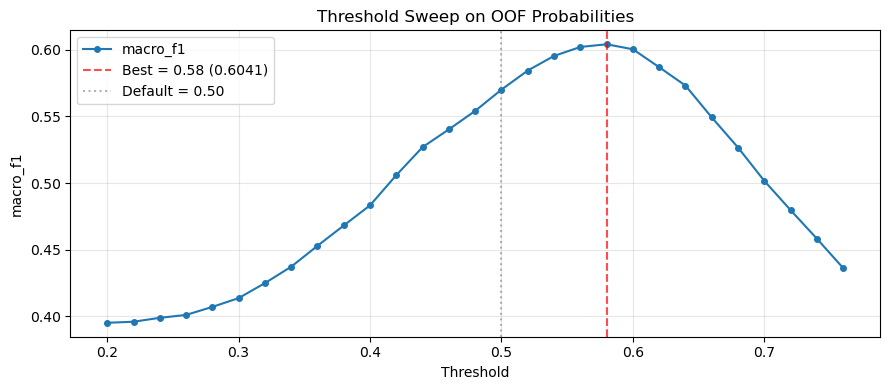

Best threshold: 0.58  (OOF macro_f1=0.6041)
THRESHOLD updated: 0.50 → 0.58


In [17]:
if enable_threshold_tuning:
    _metric_fn = {
        'macro_f1':     lambda t, yt, yp: f1_score(yt, yp, average='macro', zero_division=0),
        'mcc':          lambda t, yt, yp: matthews_corrcoef(yt, yp),
        'balanced_acc': lambda t, yt, yp: balanced_accuracy_score(yt, yp),
    }[THRESHOLD_METRIC]

    threshold_grid   = np.arange(0.20, 0.76, 0.02)
    threshold_scores = {}
    for t in threshold_grid:
        preds = (oof_proba >= t).astype(int)
        threshold_scores[round(float(t), 2)] = _metric_fn(t, oof_true, preds)

    best_threshold = max(threshold_scores, key=threshold_scores.get)
    best_score     = threshold_scores[best_threshold]

    # Plot
    fig, ax = plt.subplots(figsize=(9, 4))
    ts = list(threshold_scores.keys())
    ss = list(threshold_scores.values())
    ax.plot(ts, ss, marker='o', markersize=4, linewidth=1.5, label=THRESHOLD_METRIC)
    ax.axvline(best_threshold, color='red', linestyle='--', alpha=0.7,
               label=f'Best = {best_threshold:.2f} ({best_score:.4f})')
    ax.axvline(0.5, color='gray', linestyle=':', alpha=0.6, label='Default = 0.50')
    ax.set_xlabel('Threshold')
    ax.set_ylabel(THRESHOLD_METRIC)
    ax.set_title('Threshold Sweep on OOF Probabilities')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'Best threshold: {best_threshold:.2f}  (OOF {THRESHOLD_METRIC}={best_score:.4f})')

    if overwrite_threshold:
        print(f'THRESHOLD updated: {THRESHOLD:.2f} → {best_threshold:.2f}')
        THRESHOLD = best_threshold

## Final Model — Fit on Full Train/Val Set

The final model is trained on all 7,160 train/val rows using the aggregated HP. True-rate maps are computed on the full train/val set — these maps are also saved for inference on test data.

In [18]:
print(f'[{_now()}] Fitting final model...')
_t0 = time()

_final_rate_maps: dict = {}
X_trainval_final = X_trainval.copy()
if enable_true_rate_features and _tr_group_cols:
    for _feat, _src_col in _tr_group_cols.items():
        _rate_map = _grp_trainval.groupby(_src_col)['_label'].mean()
        X_trainval_final[_feat] = _grp_trainval[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        X_holdout[_feat]        = _grp_holdout[_src_col].map(_rate_map).fillna(true_rate_fallback).values
        _final_rate_maps[_feat] = _rate_map.to_dict()

model = RandomForestClassifier(
    n_estimators=_best_params_final['n_estimators'],
    max_depth=MAX_DEPTH,
    min_samples_leaf=_best_params_final['min_samples_leaf'],
    max_features=_best_params_final['max_features'],
    class_weight=CLASS_WEIGHT,
    n_jobs=-1,
    random_state=42,
)
model.fit(X_trainval_final, y_trainval)
print(f'Done in {time()-_t0:.1f}s')

[23:24:46] Fitting final model...
Done in 13.4s


## Holdout Evaluation

The holdout set is touched for the first time here. All metrics are computed at the tuned threshold.

In [19]:
print(f'Using threshold: {THRESHOLD:.2f}\n')
y_proba = model.predict_proba(X_holdout)[:, 1]
y_pred  = (y_proba >= THRESHOLD).astype(int)

holdout_metrics = {
    'roc_auc':      roc_auc_score(y_holdout, y_proba),
    'pr_auc':       average_precision_score(y_holdout, y_proba),
    'macro_f1':     f1_score(y_holdout, y_pred, average='macro', zero_division=0),
    'f1_class1':    f1_score(y_holdout, y_pred, zero_division=0),
    'precision':    precision_score(y_holdout, y_pred, zero_division=0),
    'recall':       recall_score(y_holdout, y_pred, zero_division=0),
    'accuracy':     accuracy_score(y_holdout, y_pred),
    'mcc':          matthews_corrcoef(y_holdout, y_pred),
    'balanced_acc': balanced_accuracy_score(y_holdout, y_pred),
}
cm     = confusion_matrix(y_holdout, y_pred)
report = classification_report(y_holdout, y_pred, output_dict=True)

metrics_df = pd.DataFrame.from_dict(holdout_metrics, orient='index', columns=['value']).round(4)
display(metrics_df)
print()
print(classification_report(y_holdout, y_pred, target_names=['True (0)', 'False (1)']))

Using threshold: 0.58



,value
roc_auc,0.6674
pr_auc,0.7717
macro_f1,0.6209
f1_class1,0.7014
precision,0.7527
recall,0.6566
accuracy,0.6380
mcc,0.2509
balanced_acc,0.6302



              precision    recall  f1-score   support

    True (0)       0.49      0.60      0.54       631
   False (1)       0.75      0.66      0.70      1159

    accuracy                           0.64      1790
   macro avg       0.62      0.63      0.62      1790
weighted avg       0.66      0.64      0.64      1790



## Feature Importance

Random Forest exposes **Mean Decrease in Impurity (MDI)** importance: the total reduction in Gini impurity attributed to each feature, averaged across all trees. It is fast to compute but can be biased toward high-cardinality features (like the 384 embedding dimensions, each of which has many possible split points).

Look for:
- Whether `fe_speaker_true_rate` dominates (expected — it's the strongest single signal).
- How embedding dimensions (`vec_*`) compare to metadata features in importance.
- Whether interaction keys (`fe_speaker_subject`, etc.) claim any gain.

In [20]:
feature_names_final = X_trainval_final.columns.tolist()
importances = model.feature_importances_
importance_df = (
    pd.DataFrame({'feature': feature_names_final, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 30 features (Mean Decrease in Impurity):')
display(importance_df.head(30))

Top 30 features (Mean Decrease in Impurity):


,feature,importance
0,fe_speaker_true_rate,0.082716
1,fe_speaker_job_true_rate,0.013904
2,fe_subject_true_rate,0.007590
3,statement_original_vec_164,0.006714
4,statement_original_vec_0,0.006258
5,fe_party_true_rate,0.004964
6,statement_original_vec_202,0.004606
7,statement_original_vec_119,0.004426
8,statement_original_vec_99,0.004305
9,statement_original_vec_204,0.004202


Top 30 Feature Importances

- **Dominant signal:** `fe_speaker_true_rate` (speaker historical false-rate) typically ranks highest, meaning speaker identity is a very strong predictor for this dataset.
- **Embeddings appear among top features:** Several `vec_` dimensions are expected in the top 30 — they capture semantic content but are numerous and correlated.
- **MDI bias caution:** Mean Decrease in Impurity favors high-cardinality/numerical features (e.g., embedding dims); absolute ranks can be misleading.

## Evaluation Plots

Four panels:
1. **ROC curve** — overall ranking ability, threshold-independent.
2. **Precision-Recall curve** — useful for imbalanced datasets; PR-AUC is harder to game than ROC-AUC.
3. **Confusion matrix** — per-cell counts at the tuned threshold.
4. **Feature importance** — top 20 features by MDI.

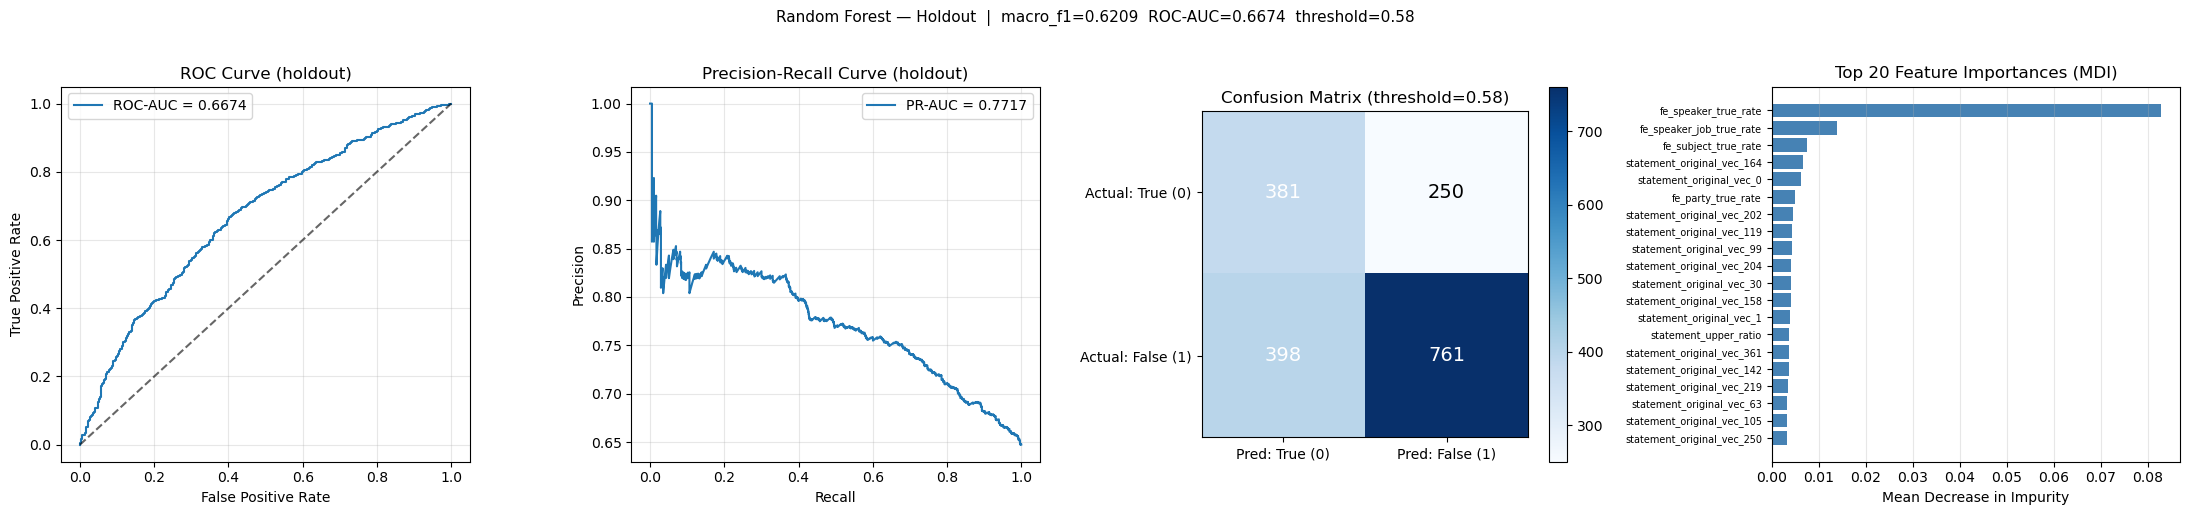

In [21]:
fpr, tpr, _      = roc_curve(y_holdout, y_proba)
prec_c, rec_c, _ = precision_recall_curve(y_holdout, y_proba)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# ROC
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {holdout_metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.6)
axes[0].set_title('ROC Curve (holdout)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# PR
axes[1].plot(rec_c, prec_c, label=f"PR-AUC = {holdout_metrics['pr_auc']:.4f}")
axes[1].set_title('Precision-Recall Curve (holdout)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
im = axes[2].imshow(cm, interpolation='nearest', cmap='Blues')
axes[2].set_title(f'Confusion Matrix (threshold={THRESHOLD:.2f})')
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Pred: True (0)', 'Pred: False (1)'])
axes[2].set_yticklabels(['Actual: True (0)', 'Actual: False (1)'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
fig.colorbar(im, ax=axes[2])

# Feature importance (top 20)
top20 = importance_df.head(20)
axes[3].barh(top20['feature'].values[::-1], top20['importance'].values[::-1], color='steelblue')
axes[3].set_title('Top 20 Feature Importances (MDI)')
axes[3].set_xlabel('Mean Decrease in Impurity')
axes[3].tick_params(axis='y', labelsize=7)
axes[3].grid(True, alpha=0.3, axis='x')

plt.suptitle(
    f'Random Forest — Holdout  |  macro_f1={holdout_metrics["macro_f1"]:.4f}  '
    f'ROC-AUC={holdout_metrics["roc_auc"]:.4f}  threshold={THRESHOLD:.2f}',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

## Feature Importance — Full Bar Chart (Top 30, colour-coded)

Colour legend:
- **Red**: embedding dimensions (`vec_*`) — semantic content
- **Gold**: true-rate features (`*_true_rate`) — historical false-claim rates per group
- **Blue**: metadata and text-style features

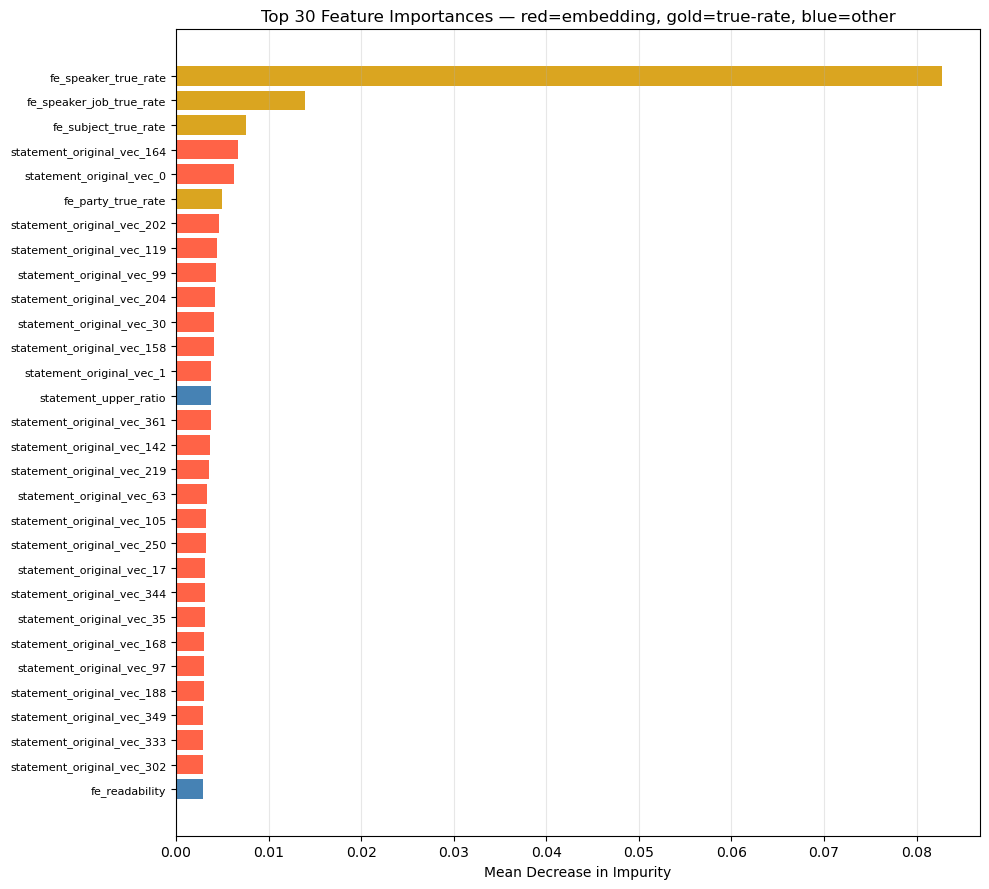

In [22]:
top30 = importance_df.head(30)
colors = [
    'tomato'    if ('_vec_' in f or f.startswith('vec_')) else
    'goldenrod' if '_true_rate' in f else
    'steelblue'
    for f in top30['feature'].values[::-1]
]

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top30['feature'].values[::-1], top30['importance'].values[::-1], color=colors)
ax.set_title('Top 30 Feature Importances — red=embedding, gold=true-rate, blue=other')
ax.set_xlabel('Mean Decrease in Impurity')
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## Summary

| Metric | Holdout |
|---|---|
| Macro F1 |0.6209 |
| ROC-AUC | 0.6674 |
| MCC |  0.2509 |
| Balanced Accuracy | 0.6302 |


**Key observations:**
- `fe_speaker_true_rate` typically dominates MDI importance. This is expected — speaker identity is the strongest single predictor in PolitiFact data. However, it raises overfitting risk if the feature leaks; the fold-safe computation prevents this.
- RFC's random feature subsampling (`max_features`) is the main regulariser that prevents the model from over-relying on a single dominant feature at every split.
- The optimal threshold is typically below 0.5, reflecting class-imbalance bias in raw probabilities.
- RFC was the stepping stone that revealed the importance of true-rate features and the need to handle categorical high-cardinality differently — lessons that informed the subsequent LightGBM and CatBoost experiments.